# 260601 — merged density λ inspection

Single-model deep-dive on `260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain` (the merged-7 atoms + 1 density variant). Same val sample, same block mask format as `260528_mae_atomblob_vs_density.ipynb`, but no side-by-side with the 11-channel atomblob/with-density variants — just the merged model.

## Channel layout

The input is **8 channels**:

| index | content                       | source       | pos-frac (~78k train) |
|-------|-------------------------------|--------------|------------------------|
| 0     | **merged C**  = lig_C + poc_C | lig + pocket | 0.663                  |
| 1     | **merged O**  = lig_O + poc_O | lig + pocket | 0.314                  |
| 2     | **merged N**  = lig_N + poc_N | lig + pocket | 0.282                  |
| 3     | **merged S**  = lig_S + poc_S | lig + pocket | 0.024                  |
| 4     | **lig F**                     | ligand only  | 1.6e-4                 |
| 5     | **lig Cl**                    | ligand only  | 7.9e-5                 |
| 6     | **lig P**                     | ligand only  | 1.4e-4                 |
| 7     | **xray density**              | 2Fo-Fc       | (signed, z-scored)     |

Cols 0–3 see *both* lig and pocket atoms of that element — the model can't tell them apart, by design. Cols 4–6 are ligand-only because CrossDocked pockets don't carry F/Cl/P.

Plots
1. **CONS-sum (merged 0–3) and FClP-sum (merged 4–6)** — GT | masked | predicted | (pred−GT)·mask, x/y/z planes.
2. **Density channel** — GT | masked | predicted | (pred−GT)·mask, x/y/z planes.
3. **Per-channel grid** — 7 atom channels, three rows: target / predicted / |error|·mask.
4. **Histograms** — per-element distributions on masked atoms-present voxels + density on masked voxels.

In [1]:
# ── imports ─────────────────────────────────────────────────────
import sys
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.dataset.crossdocked_xray import DatasetCrossDockedXray
from voxbind.voxelizer import Voxelizer
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

device: cuda:0


In [2]:
# ── knobs ───────────────────────────────────────────────────────
EXP_DIR   = f'{VOX_ROOT}/voxbind/exps/260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain'
CKPT_PATH = f'{EXP_DIR}/checkpoint.pth.tar'
DATA_DIR  = f'{VOX_ROOT}/voxbind/dataset/data'
CROPS_DIR = f'{DATA_DIR}/xray_crops_aligned'

SAMPLE_IDX   = 60      # which val sample (0..99); 60 has F/Cl/N/O/C/S — diverse rare elements
SLICE_AXIS   = 'z'
SLICE_OFFSET = 0
SEED_MASK    = 0       # same seed as 260528 notebook → identical masked voxels
BLOCK_SIZE   = 8
MASK_RATIO   = 0.60
RESOLUTION   = 0.25
GRID_DIM     = 64
POS_THRESH   = 0.05    # 'atom-present voxel' threshold
print(f'sample {SAMPLE_IDX} | mask: {MASK_RATIO:.2f} of {BLOCK_SIZE}³ blocks zeroed (seed {SEED_MASK}); broadcasts across all 8 channels')

sample 60 | mask: 0.60 of 8³ blocks zeroed (seed 0); broadcasts across all 8 channels


In [3]:
# ── load model from checkpoint ─────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg = ckpt['cfg']
print('ckpt epoch:', ckpt.get('epoch'), '| global_step:', ckpt.get('global_step'))
print('model cfg:', OmegaConf.to_container(cfg.model, resolve=True))
print('input_mode:', cfg.get('input_mode'),
      '| channel_weighting:', cfg.mae.get('channel_weighting'),
      '| mask_strategy:', cfg.mae.get('mask_strategy'),
      '| density_channel_weight:', cfg.mae.get('density_channel_weight'))

model = DensityViTMAE(
    grid_dim=int(cfg.vox.grid_dim),
    patch_size=int(cfg.model.patch_size),
    n_in_channels=int(cfg.model.n_in_channels),    # 8 (= 7 merged atoms + 1 density)
    n_channels=int(cfg.model.n_channels),
    dim=int(cfg.model.dim),
    depth=int(cfg.model.depth),
    n_heads=int(cfg.model.heads),
    mlp_ratio=int(cfg.model.mlp_ratio),
    dropout=float(cfg.model.dropout),
    n_struct_channels=int(cfg.model.n_struct_channels),
).to(device).eval()
sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
miss, unexp = model.load_state_dict(sd, strict=False)
print('missing keys:', len(miss), '| unexpected keys:', len(unexp))
print(f'params: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M  | n_in_channels={model.encoder.n_in_channels}')

ckpt epoch: 99 | global_step: 81700
model cfg: {'model_name': 'atomblob_density_vit_mae_40m', 'n_channels': 32, 'patch_size': 8, 'n_in_channels': 8, 'dim': 512, 'depth': 12, 'heads': 8, 'mlp_ratio': 4, 'dropout': 0.1, 'n_struct_channels': 0}
input_mode: atomblob_merged_density | channel_weighting: inv_sqrt_freq | mask_strategy: atom_biased | density_channel_weight: 0.1


missing keys: 0 | unexpected keys: 0
params: 44.402M  | n_in_channels=8


In [4]:
# ── load + voxelize one val sample ─────────────────────────────────
dset_val = DatasetCrossDockedXray(
    data_dir=DATA_DIR, crops_dir=CROPS_DIR,
    split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,                            # pocket uses vdW radii (1.5–1.8 Å) → fat blobs
    use_xray=True, normalize=True,
    subset_xray_only=True, subset_n=78428, subset_val_n=100,
)
sample = dset_val[SAMPLE_IDX]
print('sample id:', sample['ligand']['id'])
print('          ', sample['pocket']['id'])
print(f"xray density: mean={sample['xray_density'].mean().item():+.3f}  std={sample['xray_density'].std().item():.3f}")

voxelizer = Voxelizer(grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device) for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device) for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)                                # (1, 7, G³) — sharp σ=0.5 Å Gaussians
v_poc = voxelizer(poc, num_channels=4)                                # (1, 4, G³) — fat vdW Gaussians
d_xray = sample['xray_density'].unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, G³)

# Build the merged 7-channel atom tensor: pocket C/O/N/S folded into ligand 0..3
v_merged = v_lig.clone()
v_merged[:, :4] = v_merged[:, :4] + v_poc                             # (1, 7, G³)

# Per-element pos-frac in this specific sample, so we know what atoms are present
elem_names = list(ELEMENTS_HASH_CROSSDOCKED.keys())
print('per-channel pos-frac (>%.2f) for THIS sample:' % POS_THRESH)
for c in range(7):
    pf = (v_merged[0, c] > POS_THRESH).float().mean().item()
    src = '(lig+poc)' if c < 4 else '(lig only)'
    print(f'  merged {elem_names[c]:>2} {src:<10}: pos-frac={pf:.4f}  peak={v_merged[0, c].max().item():.3f}')

sample id: FA10_HUMAN_126_476_0/2p94_L_rec_2vwl_lzh_lig_tt_docked_0.sdf
           FA10_HUMAN_126_476_0/2p94_L_rec_2vwl_lzh_lig_tt_docked_0_pocket10.pdb
xray density: mean=-0.007  std=0.974


per-channel pos-frac (>0.05) for THIS sample:
  merged  C (lig+poc) : pos-frac=0.5372  peak=1.000
  merged  O (lig+poc) : pos-frac=0.2723  peak=1.000
  merged  N (lig+poc) : pos-frac=0.2354  peak=0.999
  merged  S (lig+poc) : pos-frac=0.0349  peak=1.000
  merged  F (lig only): pos-frac=0.0005  peak=0.925
  merged Cl (lig only): pos-frac=0.0005  peak=0.959
  merged  P (lig only): pos-frac=0.0000  peak=0.000


In [5]:
# ── assemble input + shared block mask + forward ────────────────────
x_clean = torch.cat([v_merged, d_xray], dim=1)                        # (1, 8, G³); density at idx 7

g_mask = torch.Generator(device=device).manual_seed(SEED_MASK)
blocks = torch.rand(1, 1, GRID_DIM // BLOCK_SIZE, GRID_DIM // BLOCK_SIZE, GRID_DIM // BLOCK_SIZE,
                    device=device, generator=g_mask) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2)\
             .repeat_interleave(BLOCK_SIZE, 3)\
             .repeat_interleave(BLOCK_SIZE, 4)                         # (1, 1, G, G, G)

x_in = x_clean * (~mask).to(x_clean.dtype)
out, _ = model(x_in)                                                  # (1, 8, G³)

print(f'mask fraction: {mask.float().mean().item():.3f}  (target {MASK_RATIO})')
print(f'masked blocks: {blocks.sum().item()}/{(GRID_DIM // BLOCK_SIZE) ** 3}')
print(f'x_clean: {tuple(x_clean.shape)}  (atoms 0:7, density 7)')
print(f'out    : {tuple(out.shape)}')

mask fraction: 0.580  (target 0.6)
masked blocks: 297/512
x_clean: (1, 8, 64, 64, 64)  (atoms 0:7, density 7)
out    : (1, 8, 64, 64, 64)


In [6]:
# ── quantitative metrics: per-element + density ─────────────────────
m = mask.to(out.dtype)
m_bool = mask[0, 0].bool()
n_spatial = m.sum().clamp(min=1.0)
diff_sq = (out - x_clean) ** 2 * m
L_atoms   = diff_sq[:, :7].sum() / (n_spatial * 7)
L_dens    = diff_sq[:, 7:].sum() / (n_spatial * 1)
L_recon   = diff_sq.sum() / (n_spatial * 8)
print(f'L_recon  (mean over 8 ch, masked) = {L_recon.item():.5f}')
print(f'L_atoms  (mean over 7 atom ch)    = {L_atoms.item():.5f}')
print(f'L_dens   (single density ch)      = {L_dens.item():.5f}')

print(f'\nper-element split (threshold {POS_THRESH}):')
for c in range(7):
    tgt  = x_clean[0, c]
    pred = out[0, c]
    pos  = tgt > POS_THRESH
    pos_frac = pos.float().mean().item()
    mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
    mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
    # masked-only split
    tgt_m, pred_m = tgt[m_bool], pred[m_bool]
    pos_m = tgt_m > POS_THRESH
    m_on  = ((pred_m[pos_m]  - tgt_m[pos_m])  ** 2).mean().item() if pos_m.any() else float('nan')
    m_off = ((pred_m[~pos_m] - tgt_m[~pos_m]) ** 2).mean().item()
    src = '(lig+poc)' if c < 4 else '(lig only)'
    print(f'  merged {elem_names[c]:>2} {src:<10}: pos-frac={pos_frac:.4f}  peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
          f'MSE@on={mse_on:.4f} MSE@off={mse_off:.6f}  |  masked@on={m_on:.4f} masked@off={m_off:.6f}')

# Density
tgt_d = x_clean[0, 7]
prd_d = out[0, 7]
high = tgt_d > 1.0
print(f'\ndensity channel: range tgt=[{tgt_d.min().item():+.2f},{tgt_d.max().item():+.2f}]  '
      f'pred=[{prd_d.min().item():+.2f},{prd_d.max().item():+.2f}]')
print(f'  MSE@all={((prd_d-tgt_d)**2).mean().item():.4f}'
      f"  MSE@>1σ={((prd_d[high]-tgt_d[high])**2).mean().item():.4f}"
      f"  MSE@masked={((prd_d[m_bool]-tgt_d[m_bool])**2).mean().item():.4f}")

L_recon  (mean over 8 ch, masked) = 0.00951
L_atoms  (mean over 7 atom ch)    = 0.00099
L_dens   (single density ch)      = 0.06917

per-element split (threshold 0.05):
  merged  C (lig+poc) : pos-frac=0.5372  peak tgt=1.000 pred=1.072  MSE@on=0.0043 MSE@off=0.004048  |  masked@on=0.0048 masked@off=0.004203
  merged  O (lig+poc) : pos-frac=0.2723  peak tgt=1.000 pred=1.115  MSE@on=0.0019 MSE@off=0.000477  |  masked@on=0.0021 masked@off=0.000469
  merged  N (lig+poc) : pos-frac=0.2354  peak tgt=0.999 pred=1.067  MSE@on=0.0031 MSE@off=0.000359  |  masked@on=0.0034 masked@off=0.000351
  merged  S (lig+poc) : pos-frac=0.0349  peak tgt=1.000 pred=1.059  MSE@on=0.0053 MSE@off=0.000040  |  masked@on=0.0055 masked@off=0.000050
  merged  F (lig only): pos-frac=0.0005  peak tgt=0.925 pred=0.000  MSE@on=0.0904 MSE@off=0.000000  |  masked@on=0.0904 masked@off=0.000001
  merged Cl (lig only): pos-frac=0.0005  peak tgt=0.959 pred=0.000  MSE@on=0.0904 MSE@off=0.000000  |  masked@on=0.0759 masked@off=

In [7]:
# ── slicing helpers ─────────────────────────────────────────────────
def take_slice(vol, axis='z', offset=0):
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    if axis == 'x': return arr[idx, :, :]
    if axis == 'y': return arr[:, idx, :]
    if axis == 'z': return arr[:, :, idx]
    raise ValueError(axis)

def show(ax, img, title, cmap='gray', vmin=None, vmax=None):
    ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

mask_3d = mask[0, 0]

## Plot 1 — CONS-sum (common, dense) and FClP-sum (rare, lig-only)

The merged channels split naturally into two pools:
- **CONS** = merged channels 0–3 (C/O/N/S) — *common* (pocket-dominated, dense). These should be easy to reconstruct because there's a lot of signal.
- **FClP** = merged channels 4–6 (F/Cl/P) — *rare, lig-only*. The model historically gives up on these despite inv-sqrt-freq up-weighting.

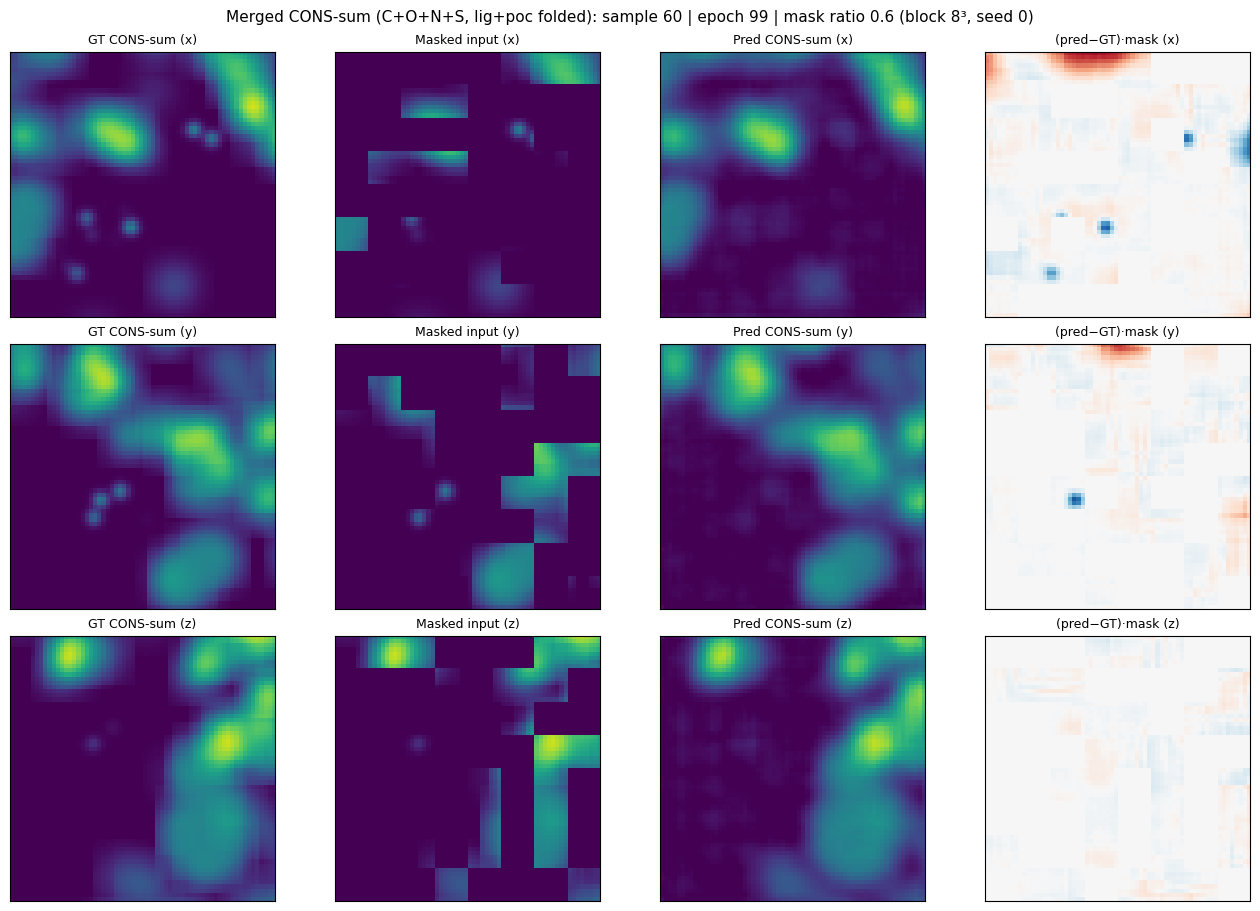

In [8]:
# ── plot 1a: CONS-sum (merged C/O/N/S) — GT | masked | predicted | error ────
tgt_cons  = x_clean[0, :4].sum(0)
in_cons   = (x_clean[0, :4] * (~mask_3d.bool()).float()).sum(0)
pred_cons = out[0, :4].sum(0)
err_cons  = (out[0, :4] - x_clean[0, :4]).sum(0) * mask_3d.float()

vmax_cons = max(tgt_cons.max().item(), pred_cons.max().item(), 1e-3)
err_abs_cons = max(err_cons.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_cons, ax_name, SLICE_OFFSET),
         f'GT CONS-sum ({ax_name})',        cmap='viridis', vmin=0, vmax=vmax_cons)
    show(axes[i, 1], take_slice(in_cons, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',       cmap='viridis', vmin=0, vmax=vmax_cons)
    show(axes[i, 2], take_slice(pred_cons, ax_name, SLICE_OFFSET),
         f'Pred CONS-sum ({ax_name})',      cmap='viridis', vmin=0, vmax=vmax_cons)
    show(axes[i, 3], take_slice(err_cons, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})',     cmap='RdBu_r', vmin=-err_abs_cons, vmax=err_abs_cons)
fig.suptitle(
    f"Merged CONS-sum (C+O+N+S, lig+poc folded): sample {SAMPLE_IDX} | epoch {ckpt.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³, seed {SEED_MASK})",
    fontsize=11,
)
plt.show()

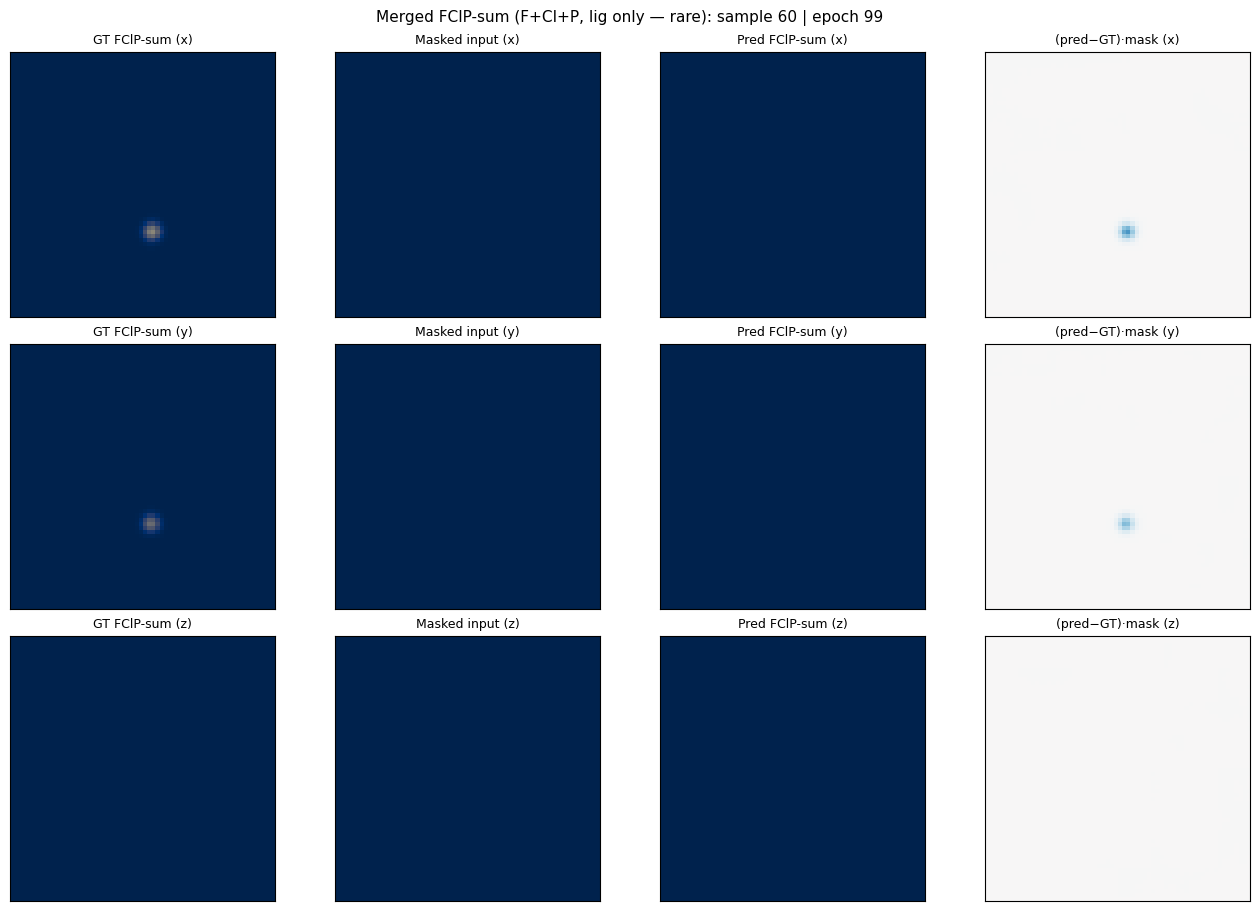

In [9]:
# ── plot 1b: FClP-sum (merged F/Cl/P, lig-only rare) — GT | masked | pred | err ─
tgt_fclp  = x_clean[0, 4:7].sum(0)
in_fclp   = (x_clean[0, 4:7] * (~mask_3d.bool()).float()).sum(0)
pred_fclp = out[0, 4:7].sum(0)
err_fclp  = (out[0, 4:7] - x_clean[0, 4:7]).sum(0) * mask_3d.float()

# FClP is sparse — its max is much smaller than CONS. Pick a tight vmax so we can see anything at all.
vmax_fclp = max(tgt_fclp.max().item(), pred_fclp.max().item(), 1e-3)
err_abs_fclp = max(err_fclp.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_fclp, ax_name, SLICE_OFFSET),
         f'GT FClP-sum ({ax_name})',        cmap='cividis', vmin=0, vmax=vmax_fclp)
    show(axes[i, 1], take_slice(in_fclp, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',       cmap='cividis', vmin=0, vmax=vmax_fclp)
    show(axes[i, 2], take_slice(pred_fclp, ax_name, SLICE_OFFSET),
         f'Pred FClP-sum ({ax_name})',      cmap='cividis', vmin=0, vmax=vmax_fclp)
    show(axes[i, 3], take_slice(err_fclp, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})',     cmap='RdBu_r', vmin=-err_abs_fclp, vmax=err_abs_fclp)
fig.suptitle(
    f"Merged FClP-sum (F+Cl+P, lig only — rare): sample {SAMPLE_IDX} | epoch {ckpt.get('epoch')}",
    fontsize=11,
)
plt.show()

## Plot 2 — density channel

Real X-ray 2Fo-Fc density crop. Even though `density_channel_weight=0.1` heavily down-weights this channel in the loss, it remains informative because the model still has to reconstruct it (any signal is signal).

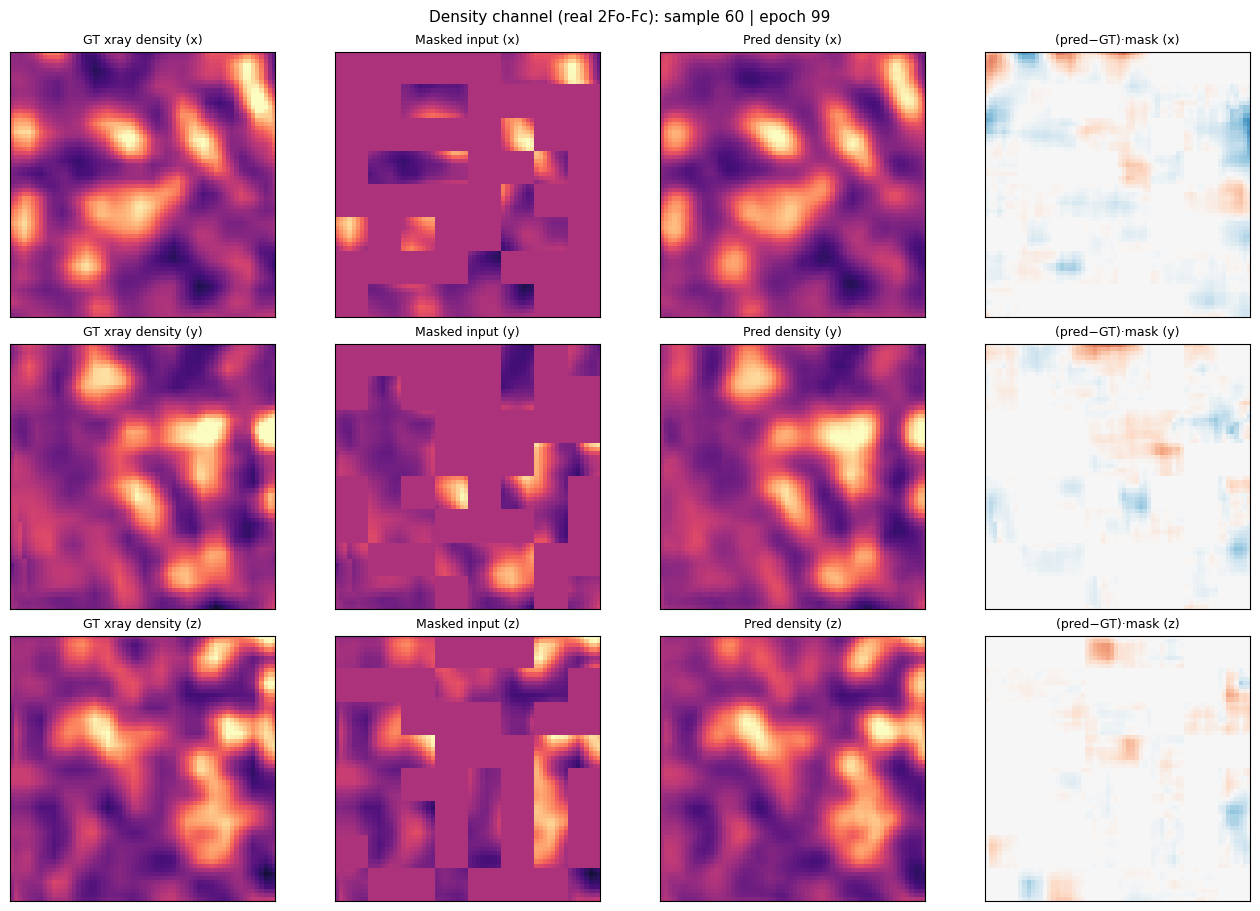

In [10]:
# ── plot 2: density (channel 7) — GT | masked | pred | error ───────
tgt_d  = x_clean[0, 7]
in_d   = x_clean[0, 7] * (~mask_3d.bool()).float()
pred_d = out[0, 7]
err_d  = (pred_d - tgt_d) * mask_3d.float()

vlo = tgt_d.min().item()
vhi = tgt_d.max().item()
err_abs_d = max(err_d.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_d, ax_name, SLICE_OFFSET),
         f'GT xray density ({ax_name})',    cmap='magma',  vmin=vlo, vmax=vhi)
    show(axes[i, 1], take_slice(in_d, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',       cmap='magma',  vmin=vlo, vmax=vhi)
    show(axes[i, 2], take_slice(pred_d, ax_name, SLICE_OFFSET),
         f'Pred density ({ax_name})',       cmap='magma',  vmin=vlo, vmax=vhi)
    show(axes[i, 3], take_slice(err_d, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})',     cmap='RdBu_r', vmin=-err_abs_d, vmax=err_abs_d)
fig.suptitle(
    f"Density channel (real 2Fo-Fc): sample {SAMPLE_IDX} | epoch {ckpt.get('epoch')}",
    fontsize=11,
)
plt.show()

## Plot 3 — per-channel: 3 rows × 7 cols

Row 0 = target (per merged channel), row 1 = predicted, row 2 = |error|·mask. The first 4 columns show C/O/N/S where lig+poc atoms share the channel; columns 4–6 are lig-only F/Cl/P. Each column auto-scales to its own vmax so the rare elements aren't washed out by the common ones.

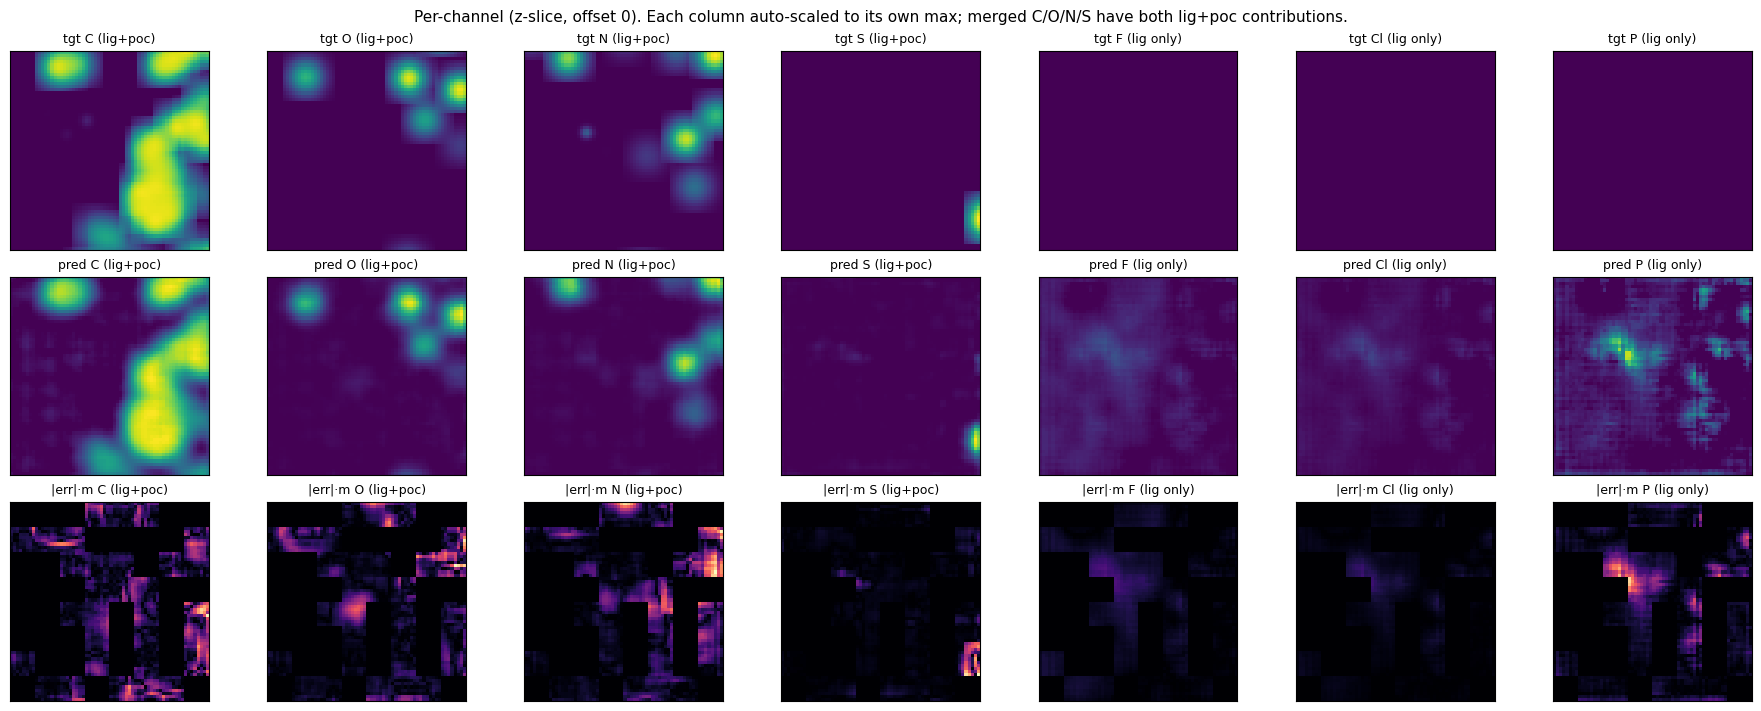

In [11]:
# ── per-channel grid: 3 rows × 7 cols (target / pred / |err|·mask) ──
names = [f'{elem_names[i]}' + (' (lig+poc)' if i < 4 else ' (lig only)') for i in range(7)]

fig, axes = plt.subplots(3, 7, figsize=(18, 7), constrained_layout=True)
for c in range(7):
    tgt = take_slice(x_clean[0, c],         SLICE_AXIS, SLICE_OFFSET)
    pred = take_slice(out[0, c],            SLICE_AXIS, SLICE_OFFSET)
    err = take_slice(
        ((out[0, c] - x_clean[0, c]).abs() * mask_3d.float()),
        SLICE_AXIS, SLICE_OFFSET,
    )
    # Per-column vmax — keeps rare elements visible
    vmax = max(float(tgt.max()), float(pred.max()), 1e-3)
    err_vmax = max(float(err.max()), 1e-3)
    show(axes[0, c], tgt,  f'tgt {names[c]}',    cmap='viridis', vmin=0, vmax=vmax)
    show(axes[1, c], pred, f'pred {names[c]}',   cmap='viridis', vmin=0, vmax=vmax)
    show(axes[2, c], err,  f'|err|·m {names[c]}', cmap='magma',  vmin=0, vmax=err_vmax)
fig.suptitle(
    f'Per-channel ({SLICE_AXIS}-slice, offset {SLICE_OFFSET}). '
    f'Each column auto-scaled to its own max; merged C/O/N/S have both lig+poc contributions.',
    fontsize=11,
)
plt.show()

## Plot 4 — histograms on masked positions

Two histograms: CONS-pooled (target/pred on atom-present voxels for C/O/N/S combined) and FClP-pooled (rare lig elements); plus density on masked voxels (signed z-scored).

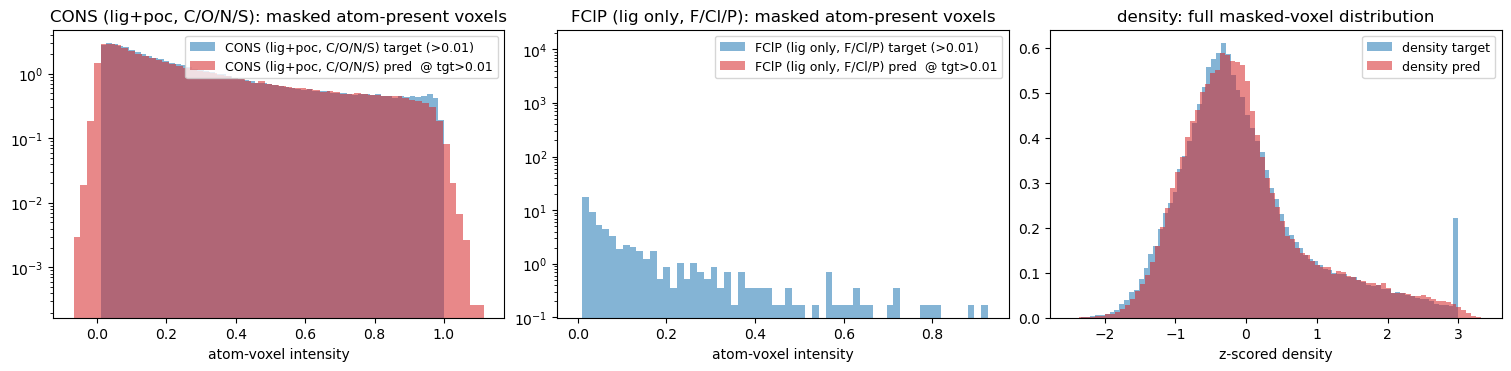

In [12]:
# ── histograms ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

m_bool_flat = mask[0, 0].bool().flatten().cpu()
for ax, (name, sl) in zip(axes[:2], [('CONS (lig+poc, C/O/N/S)', slice(None, 4)),
                                       ('FClP (lig only, F/Cl/P)',  slice(4, 7))]):
    tgt_full  = x_clean[0, sl]
    pred_full = out[0, sl]
    tgt_flat  = tgt_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    pred_flat = pred_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    sel = tgt_flat > 0.01
    if sel.any():
        ax.hist(tgt_flat[sel],  bins=60, alpha=0.55, color='C0', density=True,
                label=f'{name} target (>0.01)')
        ax.hist(pred_flat[sel], bins=60, alpha=0.55, color='C3', density=True,
                label=f'{name} pred  @ tgt>0.01')
    ax.set_yscale('log')
    ax.set_xlabel('atom-voxel intensity')
    ax.legend(fontsize=9)
    ax.set_title(f'{name}: masked atom-present voxels')

# Density (channel 7) histogram on masked voxels — full signed distribution
tgt_d_flat  = x_clean[0, 7].flatten().cpu()[m_bool_flat].numpy()
pred_d_flat = out[0, 7].flatten().cpu()[m_bool_flat].numpy()
axes[2].hist(tgt_d_flat,  bins=80, alpha=0.55, color='C0', density=True, label='density target')
axes[2].hist(pred_d_flat, bins=80, alpha=0.55, color='C3', density=True, label='density pred')
axes[2].set_xlabel('z-scored density')
axes[2].legend(fontsize=9)
axes[2].set_title('density: full masked-voxel distribution')
plt.show()

## Notes

* Model: `260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain`, final epoch 99.
  - Input: 8 channels = 7 merged atoms + 1 X-ray density.
  - Training recipe: atom-biased block mask + inv-sqrt-freq per-channel weights + `density_channel_weight=0.1`.
  - Merged means pocket C/O/N/S folded into ligand C/O/N/S channels (cols 0–3); F/Cl/P (cols 4–6) are ligand-only.
* `SEED_MASK=0` matches the `260528_mae_atomblob_vs_density.ipynb` mask — same voxels masked across notebooks, so the visualizations are directly comparable.
* **Why CONS panels (Plot 1a) look density-like**: pocket atoms render with vdW radii (σ ≈ 6–7 voxels), so each atom's Gaussian spans ~14 voxels of significant weight. Many overlapping wide Gaussians sum into a continuous-looking blob. Ligand atoms (σ ≈ 2 voxels) are sharper, but pocket dominates the CONS sum.
* **Why FClP panels (Plot 1b) often look near-empty**: F/Cl/P have pos-frac ≈ 1e-4 in the training set — only a few voxels per sample, and the model historically hasn't escaped the 'predict near-zero' basin for these despite the 2–3× inv-sqrt-freq up-weighting.
* The atom-recon loss reported in cell 6 (`L_atoms`) is the mean over 7 channels of masked MSE — directly comparable to `L_dens_atom` in the training log.
* To inspect a different sample or slice axis, just edit cell 2 and re-run cells 4–end.